## Training the Final Chess Data with RandomForest

In [49]:
import os
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

### Loaidng the Data

In [2]:
project_dir = os.path.dirname(os.getcwd())
games = pd.read_csv(os.path.join(project_dir,"data/final_chess.csv"), parse_dates=["Date"])

In [3]:
games.info()

<class 'pandas.DataFrame'>
RangeIndex: 3255656 entries, 0 to 3255655
Data columns (total 98 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   Site                    str           
 1   Date                    datetime64[us]
 2   White                   str           
 3   Black                   str           
 4   Result                  float64       
 5   WhiteElo                float64       
 6   BlackElo                float64       
 7   ECO                     str           
 8   EloDiff                 float64       
 9   absEloDiff              float64       
 10  AvgElo                  float64       
 11  HigherRatedPlayer       int64         
 12  WhiteGames              int64         
 13  WhiteWin                int64         
 14  WhiteLoss               int64         
 15  WhiteDraw               int64         
 16  BlackGames              int64         
 17  BlackWin                int64         
 18  BlackLoss    

### Preparing for Training

In [4]:
X = games.drop(columns=[
    "White", "Black", "Result", "Site", "ECO",
    # White/Black color counts
    'WasBWinRate', 'WasBLossRate', 'WasBDrawRate', 'BasWWinRate', 'BasWLossRate', 'BasWDrawRate',
    "WasBGames", "WasBWin", "WasBLoss", "WasBDraw",
    "BasWGames", "BasWWin", "BasWLoss", "BasWDraw",
])
y1 = games["Result"].map({1: 1, 0.5: 0, 0:1}) # draw or decisive
y2 = games["Result"].map({1: 2, 0.5: 1, 0: 0}) #sklearn only considers integers

"""
0 = Black win
1 = Draw
2 = White win
"""

'\n0 = Black win\n1 = Draw\n2 = White win\n'

In [5]:
Xtrain = X[(X["Date"].dt.year >= 2016) & (X["Date"].dt.year <= 2023)].drop(columns="Date")
y1train = y1[(X["Date"].dt.year >= 2016) & (X["Date"].dt.year <= 2023)].drop(columns="Date")
y2train = y2[(X["Date"].dt.year >= 2016) & (X["Date"].dt.year <= 2023)].drop(columns="Date")
Xval   = X[(X["Date"].dt.year == 2025) | (X["Date"].dt.year == 2024)].drop(columns="Date")
y1val   = y1[(X["Date"].dt.year == 2025) | (X["Date"].dt.year == 2024)].drop(columns="Date")
y2val   = y2[(X["Date"].dt.year == 2025) | (X["Date"].dt.year == 2024)].drop(columns="Date")
Xtest  = X[X["Date"].dt.year == 2026].drop(columns="Date")
y1test  = y1[X["Date"].dt.year == 2026].drop(columns="Date")
y2test  = y2[X["Date"].dt.year == 2026].drop(columns="Date")

### Random forest

In [60]:
from sklearn.ensemble import RandomForestClassifier

In [61]:
rfc = RandomForestClassifier(
    ccp_alpha=0,
    class_weight={0: 1, 1: 1.5, 2: 1},
    max_depth=40,
    max_features=0.5,
    min_samples_leaf=73,
    min_samples_split=51,
    n_estimators=195,
    bootstrap=True,
    random_state=67,
    n_jobs=-1
)

In [ ]:
#rfc.fit(Xtrain, y2train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",195
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",40
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",51
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",73
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",67
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.","{0: 1, 

In [ ]:
#joblib.dump(rfc, os.path.join(project_dir, "results/models/rfc_62_base.joblib"))

In [8]:
model_path = os.path.join(project_dir, "results/models/rfc_62_base.joblib")
rfc = joblib.load(model_path)

In [9]:
ypred = rfc.predict(Xval)

In [10]:
confusion_matrix(y2val, ypred)

array([[201150,  30047,  76940],
       [ 41168,  62055,  49750],
       [ 73574,  32436, 255332]])

In [11]:
classification_report(y2val, ypred).splitlines()

['              precision    recall  f1-score   support',
 '',
 '           0       0.64      0.65      0.64    308137',
 '           1       0.50      0.41      0.45    152973',
 '           2       0.67      0.71      0.69    361342',
 '',
 '    accuracy                           0.63    822452',
 '   macro avg       0.60      0.59      0.59    822452',
 'weighted avg       0.62      0.63      0.63    822452']

#### Testing the base rfc model on the test set

In [12]:
ypred_test = rfc.predict(Xtest)

print(confusion_matrix(y2test, ypred_test))
print(classification_report(y2test, ypred_test))

[[34049  5289 13204]
 [ 6938  9946  8594]
 [12607  5713 43148]]
              precision    recall  f1-score   support

           0       0.64      0.65      0.64     52542
           1       0.47      0.39      0.43     25478
           2       0.66      0.70      0.68     61468

    accuracy                           0.62    139488
   macro avg       0.59      0.58      0.58    139488
weighted avg       0.62      0.62      0.62    139488



In [13]:
feature_importance = pd.DataFrame({
    "feature": Xtrain.columns,
    "importance": rfc.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(30)

,feature,importance
2,EloDiff,0.274086
5,HigherRatedPlayer,0.082465
3,absEloDiff,0.080059
16,WhiteDrawRate,0.066657
19,BlackDrawRate,0.042818
51,BlackDaysSinceLastGame,0.039255
55,WinRateDiff,0.038406
50,WhiteDaysSinceLastGame,0.035683
54,WinDiff,0.033498
35,BasBDrawRate,0.017122


### Error Analysis

In [14]:
cm = confusion_matrix(y2val, ypred)

In [15]:
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
cm_percent

array([[65.27940494,  9.7511821 , 24.96941296],
       [26.91193871, 40.56598223, 32.52207906],
       [20.36131975,  8.97653746, 70.66214279]])

Draws are being confused with both decisive outcomes.<br>
Black and White are relatively easy. Draws are hard.

In [16]:
probs = rfc.predict_proba(Xval)

probs[:10]

array([[0.02513135, 0.08437313, 0.89049552],
       [0.04377588, 0.10071234, 0.85551178],
       [0.89058764, 0.08011988, 0.02929248],
       [0.80377821, 0.15905098, 0.03717081],
       [0.05750367, 0.12317487, 0.81932146],
       [0.76522098, 0.18317993, 0.05159909],
       [0.86569969, 0.10111854, 0.03318177],
       [0.02959051, 0.08393426, 0.88647523],
       [0.80634381, 0.14572023, 0.04793596],
       [0.04116184, 0.13670963, 0.82212853]])

checking the probs of matches where there are actual draw matchs

In [ ]:
draw_mask = y2val == 1
draw_probs = probs[draw_mask]
draw_probs[100:130]

array([[0.32381874, 0.19437148, 0.48180978],
       [0.71611931, 0.1274542 , 0.15642649],
       [0.46355511, 0.18562434, 0.35082055],
       [0.20170679, 0.13687638, 0.66141683],
       [0.17581608, 0.15414716, 0.67003675],
       [0.4505654 , 0.16243789, 0.38699671],
       [0.44833077, 0.16529274, 0.38637649],
       [0.3085034 , 0.35121026, 0.34028633],
       [0.47910841, 0.24965009, 0.27124151],
       [0.27091541, 0.20383198, 0.52525261],
       [0.51273426, 0.18813998, 0.29912576],
       [0.56178068, 0.15504854, 0.28317078],
       [0.61257354, 0.12855725, 0.25886921],
       [0.35450941, 0.15247451, 0.49301608],
       [0.60451053, 0.11284229, 0.28264718],
       [0.46938001, 0.19958181, 0.33103818],
       [0.51581458, 0.13178531, 0.35240011],
       [0.48099638, 0.21318248, 0.30582114],
       [0.51259041, 0.2042051 , 0.28320448],
       [0.15347137, 0.19109996, 0.65542868],
       [0.41155339, 0.34196414, 0.24648248],
       [0.35032998, 0.20593379, 0.44373623],
       [0.

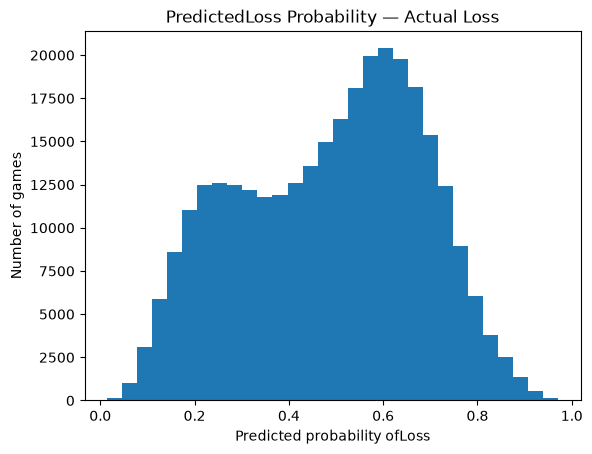

In [18]:
plt.hist(probs[y2val == 0][:, 0], bins=30)
plt.xlabel("Predicted probability ofLoss")
plt.ylabel("Number of games")
plt.title("PredictedLoss Probability — Actual Loss")
plt.show()

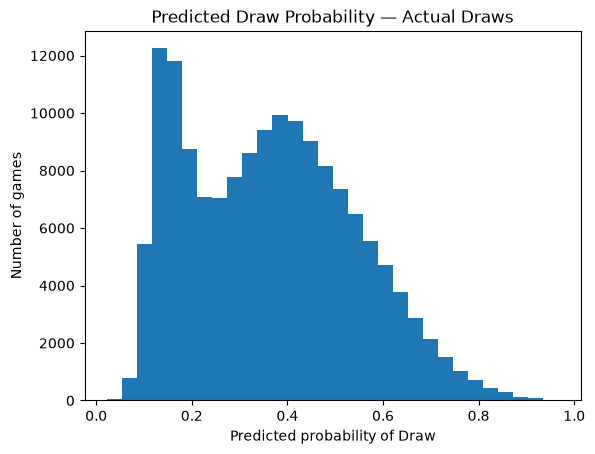

In [19]:
plt.hist(probs[y2val == 1][:, 1], bins=30)
plt.xlabel("Predicted probability of Draw")
plt.ylabel("Number of games")
plt.title("Predicted Draw Probability — Actual Draws")
plt.show()

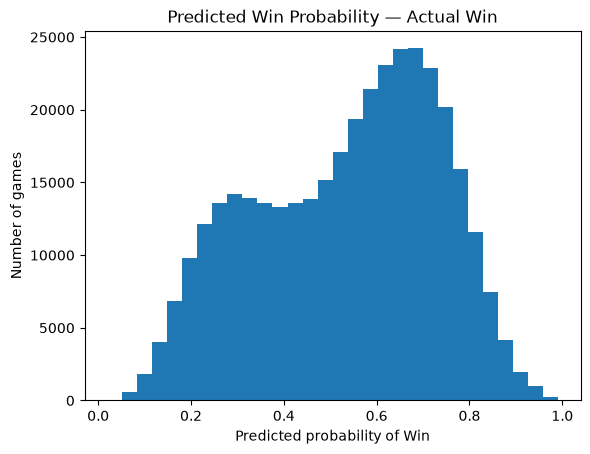

In [20]:
plt.hist(probs[y2val == 2][:, 2], bins=30)
plt.xlabel("Predicted probability of Win")
plt.ylabel("Number of games")
plt.title("Predicted Win Probability — Actual Win")
plt.show()

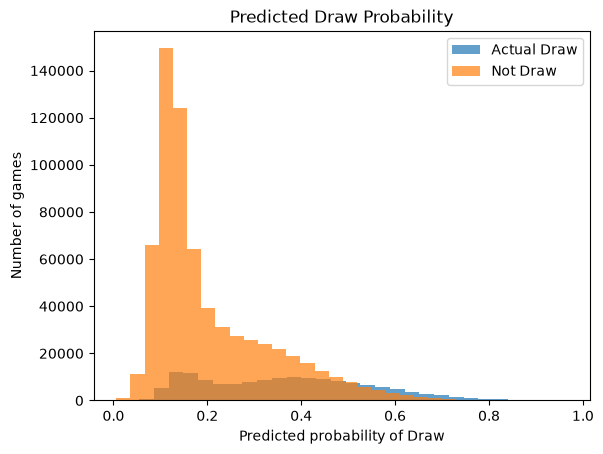

In [21]:
draw_prob = probs[:, 1]

plt.hist(draw_prob[y2val == 1], bins=30, alpha=0.7, label="Actual Draw")
plt.hist(draw_prob[y2val != 1], bins=30, alpha=0.7, label="Not Draw")

plt.xlabel("Predicted probability of Draw")
plt.ylabel("Number of games")
plt.title("Predicted Draw Probability")
plt.legend()
plt.show()

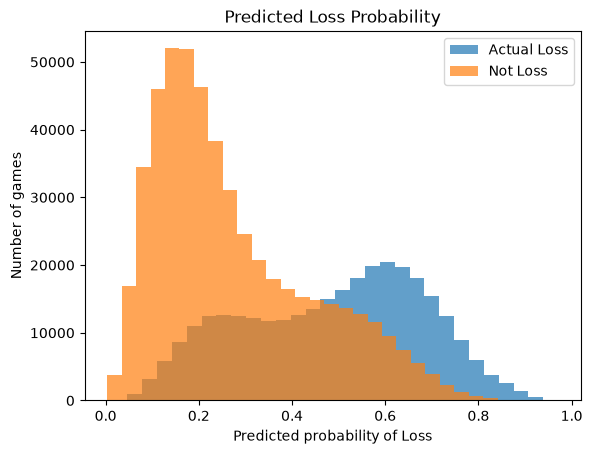

In [22]:

plt.hist(probs[y2val == 0][:,0], bins=30, alpha=0.7, label="Actual Loss")
plt.hist(probs[y2val != 0][:,0], bins=30, alpha=0.7, label="Not Loss")

plt.xlabel("Predicted probability of Loss")
plt.ylabel("Number of games")
plt.title("Predicted Loss Probability")
plt.legend()
plt.show()

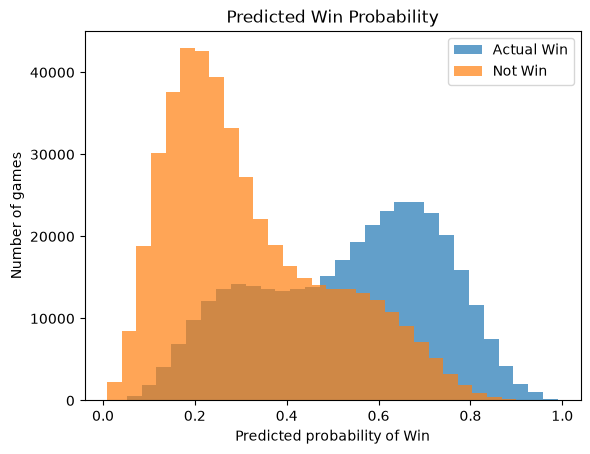

In [23]:

plt.hist(probs[y2val == 2][:,2], bins=30, alpha=0.7, label="Actual Win")
plt.hist(probs[y2val != 2][:,2], bins=30, alpha=0.7, label="Not Win")

plt.xlabel("Predicted probability of Win")
plt.ylabel("Number of games")
plt.title("Predicted Win Probability")
plt.legend()
plt.show()

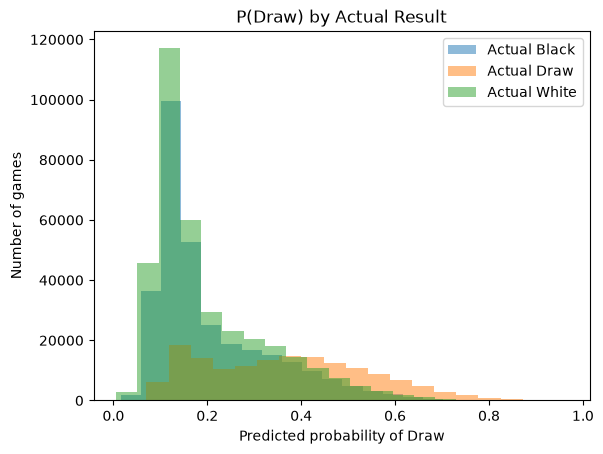

In [24]:
plt.hist(
    draw_prob[y2val == 0],
    bins=20,
    alpha=0.5,
    label="Actual Black"
)

plt.hist(
    draw_prob[y2val == 1],
    bins=20,
    alpha=0.5,
    label="Actual Draw"
)

plt.hist(
    draw_prob[y2val == 2],
    bins=20,
    alpha=0.5,
    label="Actual White"
)

plt.xlabel("Predicted probability of Draw")
plt.ylabel("Number of games")
plt.title("P(Draw) by Actual Result")
plt.legend()
plt.show()

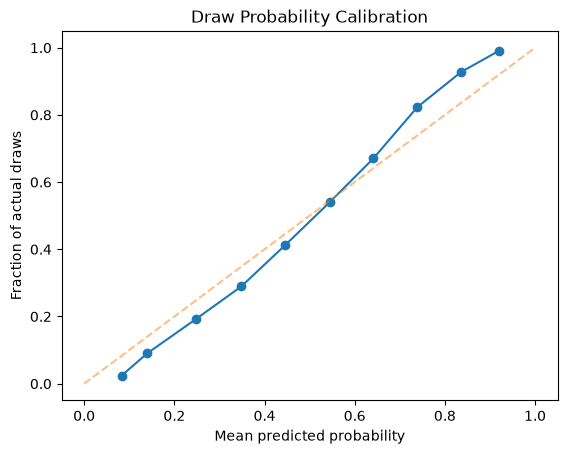

In [ ]:
actual_draw = (y2val == 1)

prob_true, prob_pred = calibration_curve(
    actual_draw,
    probs[:,1],
    n_bins=10,
    strategy="uniform"
)

plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--", alpha=0.5)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of actual draws")
plt.title("Draw Probability Calibration")
plt.show()

In [38]:
actual_draw = (y2val == 1)
roc_auc_score(actual_draw, probs[:,1])

0.7843984169763242

#### Finding a Threshold for the Draw Probability

- first doing it only on the basis of draw predictions

In [51]:
thresholds = np.arange(0.05, 0.96, 0.01)

results = []

actual_draw = (y2val == 1)

for t in thresholds:
    pred_draw = (probs[:,1] >= t)

    results.append({
        "threshold": t,
        "precision": precision_score(actual_draw, pred_draw),
        "recall": recall_score(actual_draw, pred_draw),
        "f1": f1_score(actual_draw, pred_draw)
    })

threshold_results = pd.DataFrame(results)

In [63]:
threshold_results.sort_values("f1", ascending=False)

,threshold,precision,recall,f1
26,0.31,0.416025,0.594327,0.489443
25,0.30,0.407729,0.611291,0.489178
27,0.32,0.424508,0.576906,0.489111
24,0.29,0.399525,0.627751,0.488286
28,0.33,0.433461,0.558523,0.488109
...,...,...,...,...
86,0.91,0.986667,0.000484,0.000967
87,0.92,1.000000,0.000235,0.000471
88,0.93,1.000000,0.000131,0.000261
89,0.94,1.000000,0.000059,0.000118


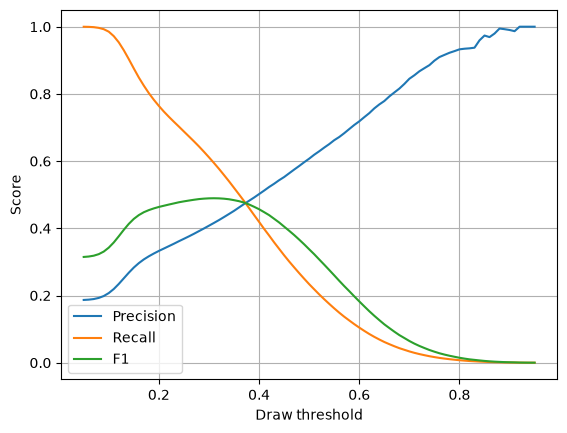

In [64]:
plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    label="F1"
)

plt.xlabel("Draw threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

In [65]:
threshold = 0.31

probs = rfc.predict_proba(Xval)

p_black = probs[:, 0]
p_draw  = probs[:, 1]
p_white = probs[:, 2]

ypred_custom = np.where(
    p_draw >= threshold,
    1,
    np.where(p_black > p_white, 0, 2)
)

In [66]:
print(confusion_matrix(y2val, ypred_custom))
print(classification_report(y2val, ypred_custom))

[[180462  59334  68341]
 [ 28891  90916  33166]
 [ 66152  68285 226905]]
              precision    recall  f1-score   support

           0       0.66      0.59      0.62    308137
           1       0.42      0.59      0.49    152973
           2       0.69      0.63      0.66    361342

    accuracy                           0.61    822452
   macro avg       0.59      0.60      0.59    822452
weighted avg       0.63      0.61      0.61    822452



- Now doing it on the macro f1, accuracy, draw f1

In [75]:
thresholds = np.arange(0.20, 0.61, 0.01)

results = []

for threshold in thresholds:

    ypred_custom = np.where(
        p_draw >= threshold,
        1,
        np.where(p_black > p_white, 0, 2)
    )

    results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y2val, ypred_custom),
        "macro_f1": f1_score(y2val, ypred_custom, average="macro"),
        "black_f1": f1_score(y2val, ypred_custom, labels=[0], average=None)[0],
        "draw_f1": f1_score(y2val, ypred_custom, labels=[1], average=None)[0],
        "white_f1": f1_score(y2val, ypred_custom, labels=[2], average=None)[0]
    })

threshold_results = pd.DataFrame(results)

In [76]:
threshold_results.sort_values("draw_f1", ascending=False).head(5)

,threshold,accuracy,macro_f1,black_f1,draw_f1,white_f1
11,0.31,0.605851,0.588591,0.618400,0.489443,0.657930
10,0.30,0.601571,0.585693,0.614100,0.489178,0.653800
12,0.32,0.609738,0.591015,0.621956,0.489111,0.661978
9,0.29,0.596888,0.582348,0.609683,0.488286,0.649076
13,0.33,0.613484,0.593173,0.625663,0.488109,0.665748


In [77]:
threshold_results.sort_values("macro_f1", ascending=False).head(5)

,threshold,accuracy,macro_f1,black_f1,draw_f1,white_f1
17,0.37,0.624843,0.597135,0.637021,0.476598,0.677787
16,0.36,0.622591,0.596904,0.634750,0.480709,0.675253
18,0.38,0.626699,0.596719,0.639237,0.470926,0.679993
15,0.35,0.619763,0.595981,0.631908,0.483756,0.672278
19,0.39,0.628152,0.595721,0.641108,0.464123,0.681933


In [78]:
threshold_results.sort_values("accuracy", ascending=False).head(5)

,threshold,accuracy,macro_f1,black_f1,draw_f1,white_f1
24,0.44,0.631575,0.584468,0.647580,0.417442,0.688381
25,0.45,0.631399,0.580786,0.648127,0.405065,0.689164
23,0.43,0.631385,0.587519,0.646699,0.428381,0.687477
26,0.46,0.631259,0.577098,0.648728,0.392759,0.689807
22,0.42,0.631107,0.590454,0.645714,0.439261,0.686387


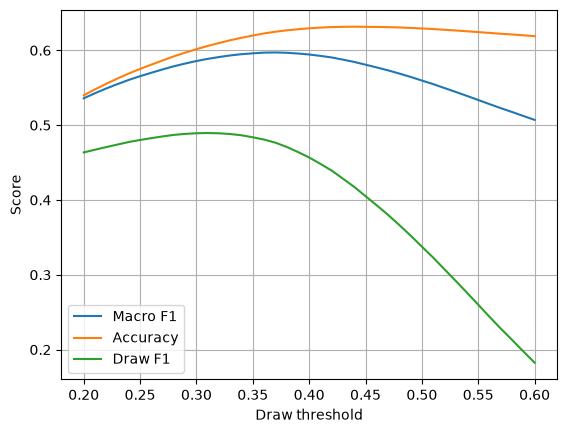

In [79]:
plt.plot(
    threshold_results["threshold"],
    threshold_results["macro_f1"],
    label="Macro F1"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["accuracy"],
    label="Accuracy"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["draw_f1"],
    label="Draw F1"
)

plt.xlabel("Draw threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

From the above observation, we need a threshld for draw probability which maximizes the macro_f1,<br>
so we choose "0.37" as the best threshold and test it validation set.

In [73]:
threshold = 0.37

probs_val = rfc.predict_proba(Xval)

p_black = probs_val[:, 0]
p_draw = probs_val[:, 1]
p_white = probs_val[:, 2]

ypred_val = np.where(
    p_draw >= threshold,
    1,
    np.where(p_black > p_white, 0, 2)
)

In [74]:
print(confusion_matrix(y2val, ypred_val))
print(classification_report(y2val, ypred_val))

[[194941  38489  74707]
 [ 36775  73600  42598]
 [ 72186  43794 245362]]
              precision    recall  f1-score   support

           0       0.64      0.63      0.64    308137
           1       0.47      0.48      0.48    152973
           2       0.68      0.68      0.68    361342

    accuracy                           0.62    822452
   macro avg       0.60      0.60      0.60    822452
weighted avg       0.63      0.62      0.63    822452



##### finally testing this on Xtest

In [93]:
threshold = 0.37

probs_test = rfc.predict_proba(Xtest)

p_black = probs_test[:, 0]
p_draw = probs_test[:, 1]
p_white = probs_test[:, 2]

ypred_test = np.where(
    p_draw >= threshold,
    1,
    np.where(p_black > p_white, 0, 2)
)

In [94]:
print(confusion_matrix(y2test, ypred_test))
print(classification_report(y2test, ypred_test))

[[33192  6361 12989]
 [ 6430 11355  7693]
 [12530  7299 41639]]
              precision    recall  f1-score   support

           0       0.64      0.63      0.63     52542
           1       0.45      0.45      0.45     25478
           2       0.67      0.68      0.67     61468

    accuracy                           0.62    139488
   macro avg       0.59      0.58      0.59    139488
weighted avg       0.62      0.62      0.62    139488

